In [1]:
from pathlib import Path
import os
import sys

print("Current working directory:")
print(Path.cwd())

print("\nParents:")
for i, p in enumerate(Path.cwd().parents):
    print(i, p)

print("\nCurrent sys.path:")
for p in sys.path:
    print(p)


Current working directory:
/Users/griffen/Desktop/predictive-maintenance-nuclear/notebooks

Parents:
0 /Users/griffen/Desktop/predictive-maintenance-nuclear
1 /Users/griffen/Desktop
2 /Users/griffen
3 /Users
4 /

Current sys.path:
/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python39.zip
/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9
/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/lib-dynload

/Users/griffen/Desktop/predictive-maintenance-nuclear/venv/lib/python3.9/site-packages


In [2]:
import sys 
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from src.data_loader import load_fd001_data, add_normal_operation_flag

df = load_fd001_data("data/raw/train_FD001.txt")
df = add_normal_operation_flag(df)


In [3]:
# picking one engine to inspect 

engine_id = 1

df_engine = df[df['engine_id'] == engine_id]



choose 3 sensors 

sensor_1 = constant 
sensor_3 = medeum variance 
sensor_14 = high variance 

plots for each sensor below:

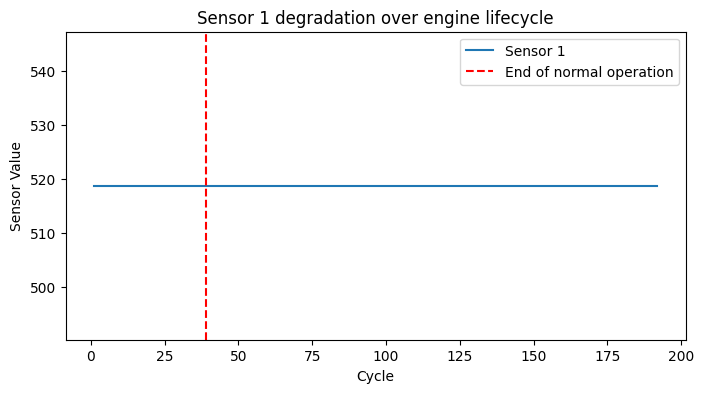

In [4]:
# sensor 1 plot 

plt.figure(figsize = (8,4))
plt.plot(df_engine["cycle"], df_engine["sensor_1"], label = "Sensor 1")
plt.axvline(
    x = df_engine[df_engine["is_normal_operation"] == False]["cycle"].min(),
    linestyle = "--",
    color = "red",
    label = "End of normal operation"
)

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor 1 degradation over engine lifecycle")
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

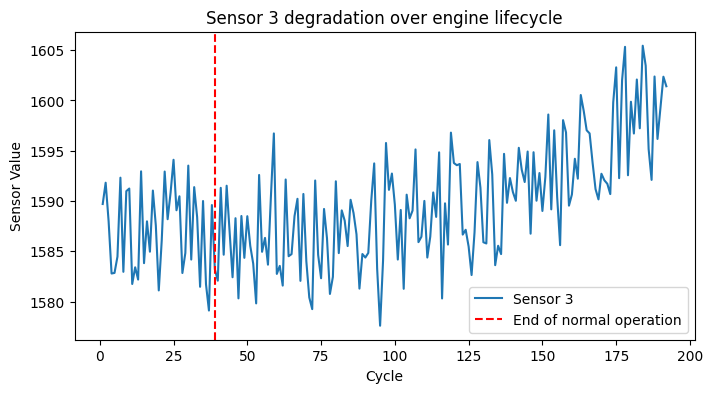

In [5]:
#sensor 3 plot 

plt.figure(figsize=(8,4))
plt.plot(df_engine["cycle"], df_engine["sensor_3"], label = "Sensor 3")
plt.axvline(
    x = df_engine[df_engine['is_normal_operation'] == False]['cycle'].min(),
    linestyle = "--",
    color = "red",
    label = "End of normal operation"
    )

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor 3 degradation over engine lifecycle")
plt.legend()
plt.show

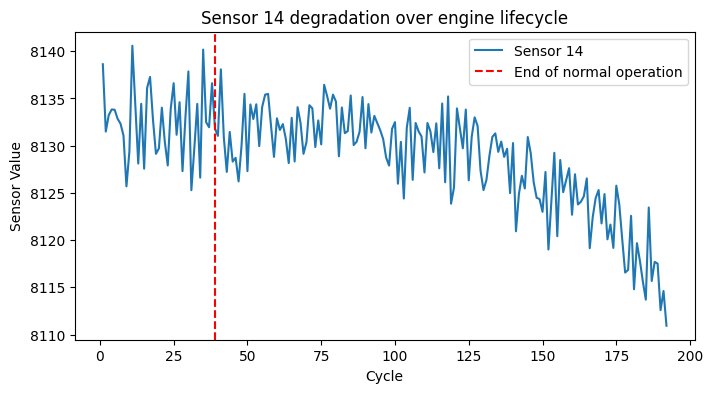

In [6]:
plt.figure(figsize = (8,4))
plt.plot(df_engine['cycle'], df_engine['sensor_14'], label = "Sensor 14")
plt.axvline(
    x = df_engine[df_engine['is_normal_operation'] == False]['cycle'].min(),
    linestyle = "--",
    color = "red",
    label = "End of normal operation"
)

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor 14 degradation over engine lifecycle")
plt.legend()
plt.show()

during stable operation the engines operate with in a range of aprox 15 

then the engines appear to drift slowly outside of this range over time 

these sensors would help to detect early degradation with the exception of sensor 1 which is constant and provides not information at all 

i would trust sensors 3 and 14 for safety critical systesm 

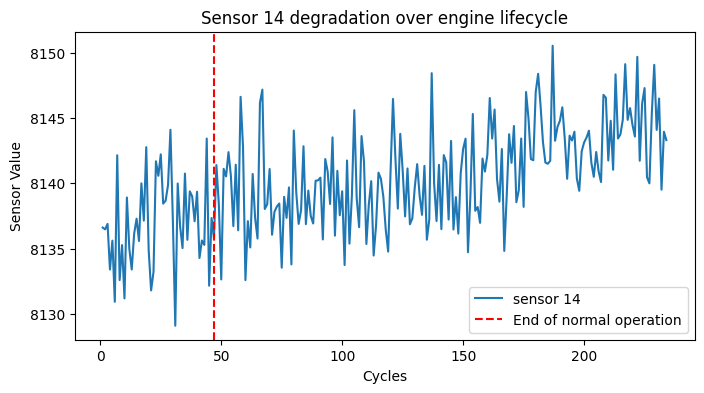

In [7]:
#sanity check on sensor 14 to confirm its behaviour is broadly similar 

engine_id_sanity = 20

df_engine_sanity = df[df['engine_id'] == engine_id_sanity]

plt.figure(figsize = (8,4))
plt.plot(df_engine_sanity['cycle'], df_engine_sanity['sensor_14'], label = "sensor 14")
plt.axvline (
    x = df_engine_sanity[df_engine_sanity['is_normal_operation'] == False]['cycle'].min(),
    linestyle = "--",
    color = "red",
    label = "End of normal operation"
)

plt.xlabel('Cycles')
plt.ylabel('Sensor Value')
plt.title('Sensor 14 degradation over engine lifecycle')
plt.legend()
plt.show()

Sensor 1 exhibits zero variance across all engines and cycles, providing no information for degradation modeling. It will be excluded from features.

Sensors 3 and 14 show measurable variation during the early cycles, making them informative for predictive maintenance. These sensors will form the core input features.

Post-normal-operation sensor trends differ between engines, highlighting inter-engine variability. Sensor 14 may increase or decrease depending on the individual engine lifecycle. The predictive model must account for these differences.

In [8]:
#compute variance during normal operation 

sensor_cols = [col for col in df.columns if "sensor" in col]
variance_df = df[df['is_normal_operation']][sensor_cols].var().sort_values(ascending=False)

print("Sensor variance during normal operation:")
print(variance_df)

Sensor variance during normal operation:
sensor_9     6.939224e+01
sensor_14    6.357148e+01
sensor_4     3.495284e+01
sensor_3     2.135915e+01
sensor_17    1.281662e+00
sensor_7     3.911465e-01
sensor_12    2.556187e-01
sensor_2     1.412733e-01
sensor_11    3.089109e-02
sensor_20    1.665030e-02
sensor_21    6.177941e-03
sensor_13    3.026748e-03
sensor_8     3.023002e-03
sensor_15    7.013067e-04
sensor_6     4.311782e-06
sensor_5     1.262496e-29
sensor_10    1.972650e-31
sensor_16    1.926416e-34
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_1     0.000000e+00
dtype: float64


top 5 sensors: 9, 14, 4, 3, 17 

these sensors exhibit the largest varience during normal operation and will be the most informative about degradation 


In [9]:
#selecting only top sensors 
selected_sensors = ['sensor_9', 'sensor_14', 'sensor_4', 'sensor_3', 'sensor_17']

#create a reduced dataframe for modeling 
df_model = df[['engine_id', 'cycle', 'is_normal_operation'] + selected_sensors].copy()

print(df_model.head())
print(df_model.shape)


   engine_id  cycle  is_normal_operation  sensor_9  sensor_14  sensor_4  \
0          1      1                 True   9046.19    8138.62   1400.60   
1          1      2                 True   9044.07    8131.49   1403.14   
2          1      3                 True   9052.94    8133.23   1404.20   
3          1      4                 True   9049.48    8133.83   1401.87   
4          1      5                 True   9055.15    8133.80   1406.22   

   sensor_3  sensor_17  
0   1589.70        392  
1   1591.82        392  
2   1587.99        390  
3   1582.79        392  
4   1582.85        393  
(20631, 8)


We retain only the top 5 sensors by variance during normal operation, removing near-constant sensors that do not contribute meaningful information. This reduces model complexity and focuses on features that capture degradation trends.

becasue engines show inter-engine variability (sensor 14 increased for engine 20 but decreased for engine 1) normalization will be critical 

below normalization is applied per sensor using min-max scaling over normal operation cycles keeping the model safe from engine to engine baseline shifts

In [10]:
scalers = {}

for sensor in selected_sensors:
    scaler = MinMaxScaler()

    #fit on normal operation only 
    normal_values = df_model[df_model['is_normal_operation']][sensor].values.reshape(-1,1)
    scaler.fit(normal_values)

    #transform all cycles 
    df_model[sensor] = scaler.transform(df_model[sensor].values.reshape(-1,1))

    #store for later use 
    scalers[sensor] = scaler

#sanity check 
print(df_model[selected_sensors].head())

   sensor_9  sensor_14  sensor_4  sensor_3  sensor_17
0  0.288710   0.530226  0.450639  0.595215      0.500
1  0.243804   0.373489  0.513016  0.662839      0.500
2  0.431688   0.411739  0.539047  0.540670      0.250
3  0.358399   0.424929  0.481827  0.374801      0.500
4  0.478500   0.424269  0.588654  0.376715      0.625


Scaling by normal operation ensures the model learns deviations relative to the healthy baseline, which mirrors nuclear practice — detect anomalies relative to safe operating conditions.

In [11]:
#create sequences for modeling 
def create_sequences(df, sensors, seq_length=30):
    sequences = []
    engine_ids = df['engine_id'].unique()

    for eng in engine_ids:
        df_eng = df[df['engine_id'] == eng]
        data = df_eng[sensors].values
        for start in range(len(data) - seq_length + 1):
            seq = data[start:start + seq_length]
            sequences.append(seq)
    return np.array(sequences)

seq_length = 30 

X_sequences = create_sequences(df_model, selected_sensors, seq_length)

print("Sequence Shape:", X_sequences.shape)

Sequence Shape: (17731, 30, 5)


Sequences of 30 cycles capture short-term temporal trends in sensor readings. This allows the model to learn gradual degradation patterns while remaining sensitive to deviations beyond normal operation.

In [12]:
# labeling sequences for anomaly detection 
#only sequences fully in normal operation -> training sequences 
#later, sequences containing degraded cycles -> evaluation sequnces and anomally detaction 

labels = []

for eng in df_model['engine_id'].unique():
    df_eng = df_model[df_model['engine_id'] == eng]
    is_normal = df_eng['is_normal_operation'].values
    for start in range(len(is_normal) - seq_length + 1):
        seq_normal = is_normal[start:start + seq_length]
        labels.append(seq_normal.all()) #--> true if all cycles in seq are normal 

labels = np.array(labels)
print("Number of sequences labeled normal:", labels.sum())


Number of sequences labeled normal: 1075


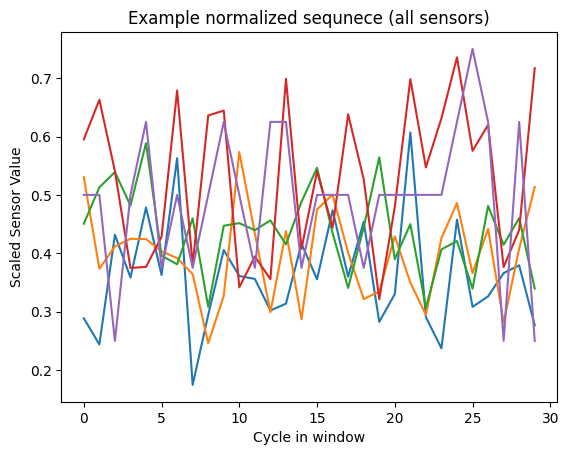

In [13]:
# verify sequneces visually 
plt.plot(X_sequences[0])
plt.title("Example normalized sequnece (all sensors)")
plt.xlabel("Cycle in window")
plt.ylabel("Scaled Sensor Value")
plt.show()

In [14]:
#confirm lables make sense 
print("Fraction of sequences fully normal:", labels.mean())

Fraction of sequences fully normal: 0.06062827815690034


Only a small fraction of operational windows represent fully healthy behavior, reflecting the conservative definition of normal operation and the long degradation tails typical of safety-critical systems.

Model Phase 1 — LSTM Autoencoder (Reconstruction-Based)

Learn what normal looks like → flag deviations

In [15]:
#isolate training data 

X_train = X_sequences[labels == True]

print("Training sequences shape:", X_train.shape)

Training sequences shape: (1075, 30, 5)
